<a href="https://colab.research.google.com/github/Love1117/Machine_learning-Projects/blob/main/Machine_Learning%20Project/03_Deep%20Learning%20Projects/Convolutional%20Neural%20Network%20(CNN)/Flower%20photos%20classification(5%20types)/flower_dataset_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import matplotlib.pyplot as plt
import PIL
import os
import numpy as np
import pathlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Loading Dataset from drive**

In [2]:

dataset_dir = "/content/drive/My Drive/flower_dataset/flower_photos"

data_dir = pathlib.Path(dataset_dir)

print(data_dir)

/content/drive/My Drive/flower_dataset/flower_photos


#**Counting total length of images**

In [3]:
image_count = len(list(data_dir.glob('*/*.jpg')))

print(image_count)

3670


#**Create Label Dictionary**

In [4]:
flower_dict = {
    'daisy': 0,
    'dandelion': 1,
    'roses': 2,
    'sunflowers': 3,
    'tulips': 4
}

#**Converting image to python readable format Using pathlib + cv2**

In [5]:
X = []
y = []

for flower_name in flower_dict:

    flower_folder = data_dir / flower_name

    for image_path in flower_folder.glob('*.jpg'):

        img = cv2.imread(str(image_path))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (180,180))

        X.append(img)

        y.append(flower_dict[flower_name])

#**Convert to NumPy Arrays**

In [6]:
X = np.array(X)
y = np.array(y)

# Normalize Images
X = X / 255.0

#**Show Sample Image**

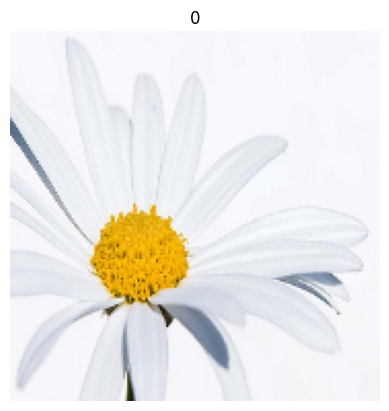

In [7]:
plt.imshow(X[0])
plt.title(y[0])
plt.axis("off")
plt.show()

#**Check Shapes**

In [8]:
print(X.shape)
print(y.shape)


(3670, 180, 180, 3)
(3670,)


#**Split Dataset**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#**Improved CNN Model With Data Augmentation**

In [10]:
data_augumentation = keras.Sequential([layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
                                       layers.RandomRotation(0.1),
                                       layers.RandomZoom(0.1)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#**Build CNN Model**

In [11]:
model = Sequential([
        data_augumentation,

        layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(180,180,3)
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Dropout(0.2),
    layers.Flatten(),


    layers.Dense(128, activation='relu'),

    layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#**Compile Model**

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


#**Training Model**

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_test, y_test))

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.3879 - loss: 1.4215 - val_accuracy: 0.4755 - val_loss: 1.2703
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.5545 - loss: 1.0887 - val_accuracy: 0.5490 - val_loss: 1.1405
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6093 - loss: 0.9799 - val_accuracy: 0.5967 - val_loss: 1.0220
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.6550 - loss: 0.8942 - val_accuracy: 0.6090 - val_loss: 1.0270
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.6737 - loss: 0.8509 - val_accuracy: 0.6253 - val_loss: 0.9957
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6873 - loss: 0.7808 - val_accuracy: 0.6485 - val_loss: 0.9398
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.7159 - loss: 0.7390 - val_accuracy: 0.6608 - val_loss: 0.9132
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7289 - loss: 0.7057 - val_accuracy: 0.6431 -

#**Evaluate Model**

In [14]:
model.evaluate(X_test, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7439 - loss: 0.9315


[0.9315347075462341, 0.7438691854476929]

#**Plot Accuracy and Loss**

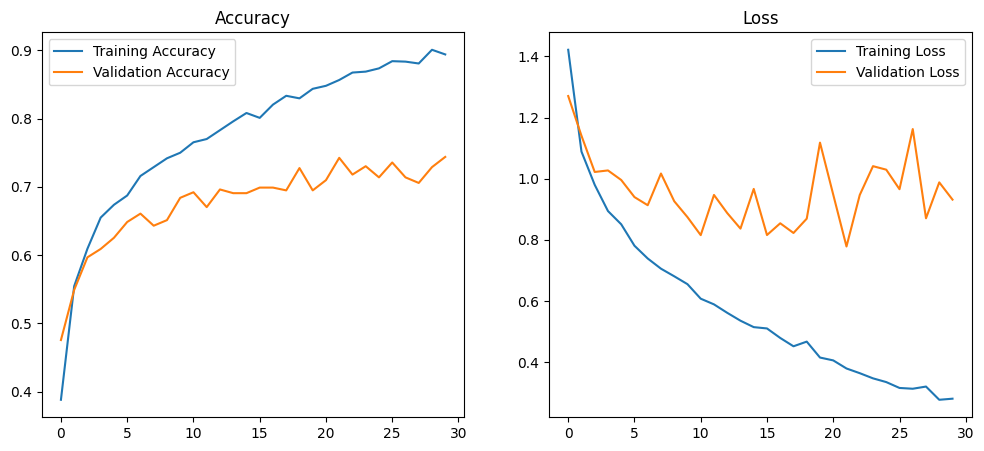

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(30)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [16]:
sample_image = X_test[0]

In [17]:
classes = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

#**Predict**

In [18]:
prediction = model.predict(
    np.expand_dims(sample_image, axis=0)
)

predicted_class = classes[np.argmax(prediction)]

print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
sunflowers


In [19]:
model.save("/content/drive/My Drive/flower_dataset/flower_classifier.keras")